In [1]:

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
     

X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)
     

df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,2.458419,2.457877,-0.030899,0.926574,-0.044071,1
1,0.288099,0.904405,1.205857,2.255231,-1.722949,1
2,-1.868486,1.560593,0.430363,-1.237807,4.211382,0
3,-0.615013,-2.034830,-1.766568,-1.192833,-1.150303,0
4,-0.977220,-2.825349,-3.678121,-1.710265,-1.381129,0


In [2]:
import random
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)
     

# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df
     

# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [4]:
df1 = combined_sampling(df,0.5,0.5)

In [5]:

df2 = combined_sampling(df,0.5,0.5)

In [6]:

df3 = combined_sampling(df,0.5,0.5)

In [7]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col4', 'target'], dtype='str')
Index(['col4', 'col2', 'target'], dtype='str')
Index(['col3', 'col1', 'target'], dtype='str')


In [8]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()
     

clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

[Text(0.4166666666666667, 0.9166666666666666, 'x[0] <= -0.054\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.13333333333333333, 0.75, 'x[0] <= -0.379\ngini = 0.105\nsamples = 18\nvalue = [17, 1]'),
 Text(0.275, 0.8333333333333333, 'True  '),
 Text(0.06666666666666667, 0.5833333333333334, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.2, 0.5833333333333334, 'x[1] <= 0.141\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.13333333333333333, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.26666666666666666, 0.4166666666666667, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.7, 0.75, 'x[0] <= 1.941\ngini = 0.264\nsamples = 32\nvalue = [5, 27]'),
 Text(0.5583333333333333, 0.8333333333333333, '  False'),
 Text(0.5333333333333333, 0.5833333333333334, 'x[1] <= -1.231\ngini = 0.191\nsamples = 28\nvalue = [3, 25]'),
 Text(0.4, 0.4166666666666667, 'x[1] <= -1.909\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.3333333333333333, 0.25, 'gini 

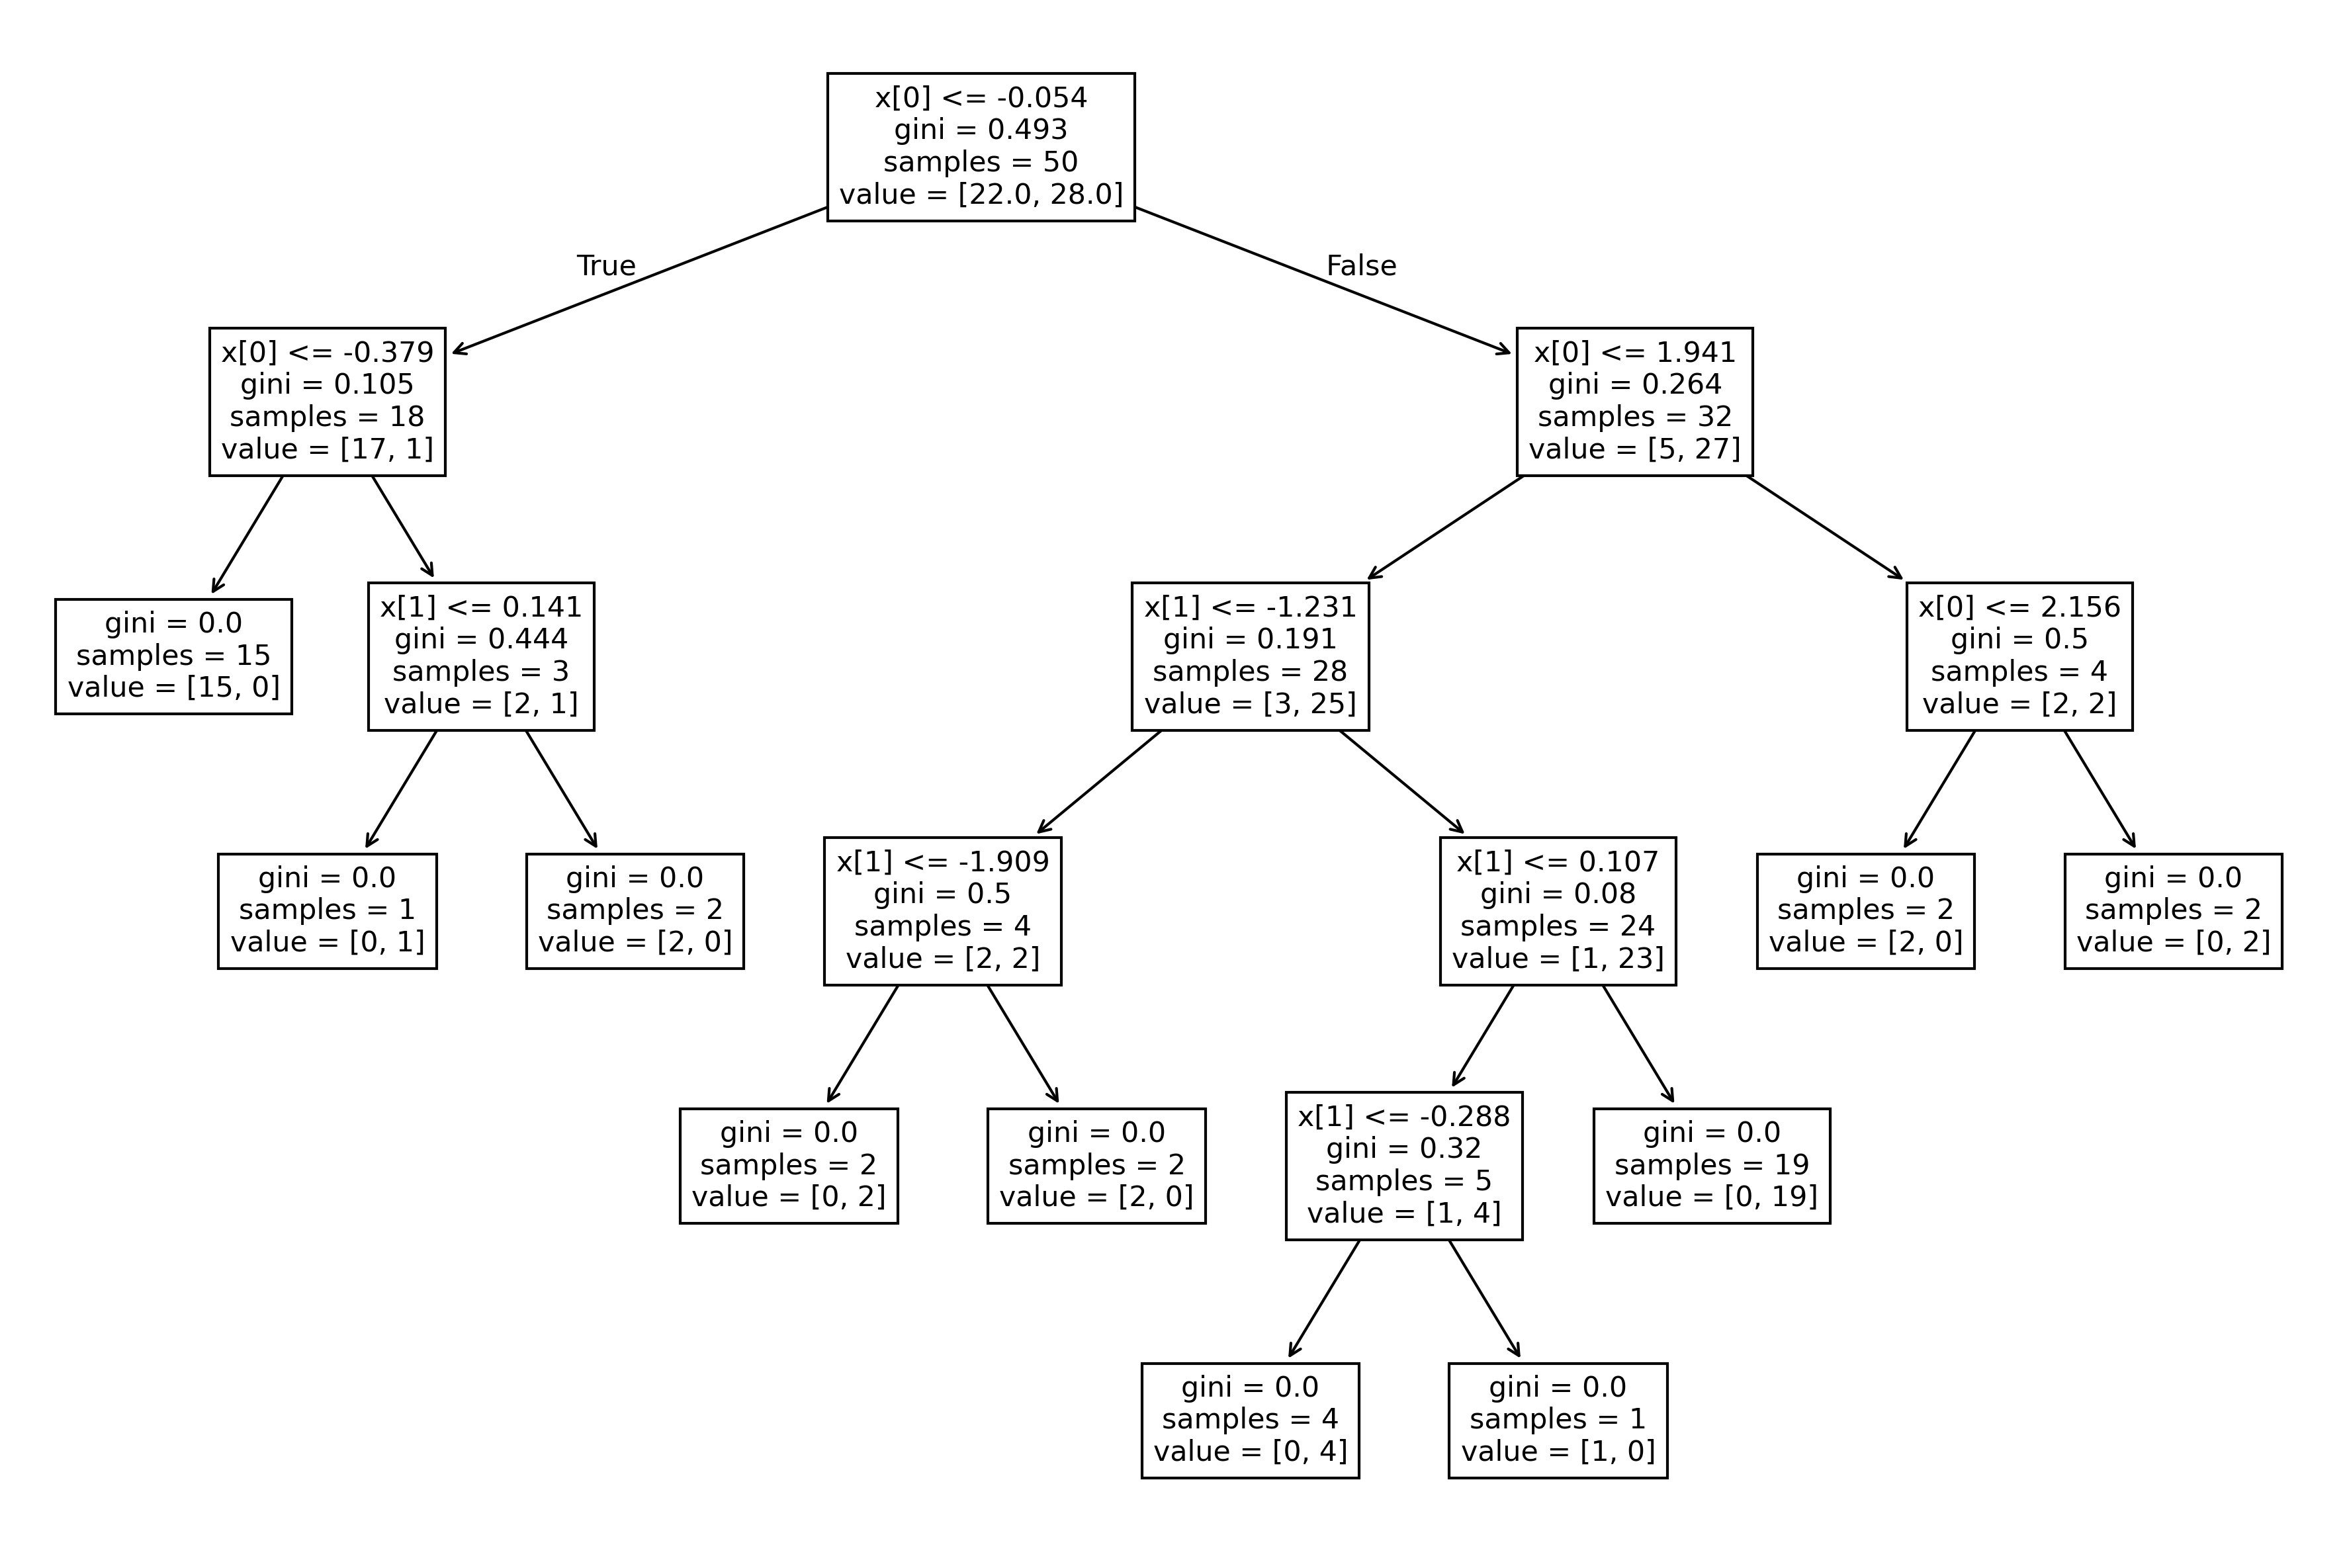

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt  
plt.figure(figsize=(15, 10), dpi=300)
plot_tree(clf1)

[Text(0.5, 0.9166666666666666, 'x[1] <= -0.299\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.3333333333333333, 0.75, 'gini = 0.0\nsamples = 26\nvalue = [26, 0]'),
 Text(0.41666666666666663, 0.8333333333333333, 'True  '),
 Text(0.6666666666666666, 0.75, 'x[0] <= -0.674\ngini = 0.153\nsamples = 24\nvalue = [2, 22]'),
 Text(0.5833333333333333, 0.8333333333333333, '  False'),
 Text(0.5, 0.5833333333333334, 'x[0] <= -0.955\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.3333333333333333, 0.4166666666666667, 'x[1] <= 0.721\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.16666666666666666, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5, 0.25, 'x[0] <= -3.052\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.3333333333333333, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nval

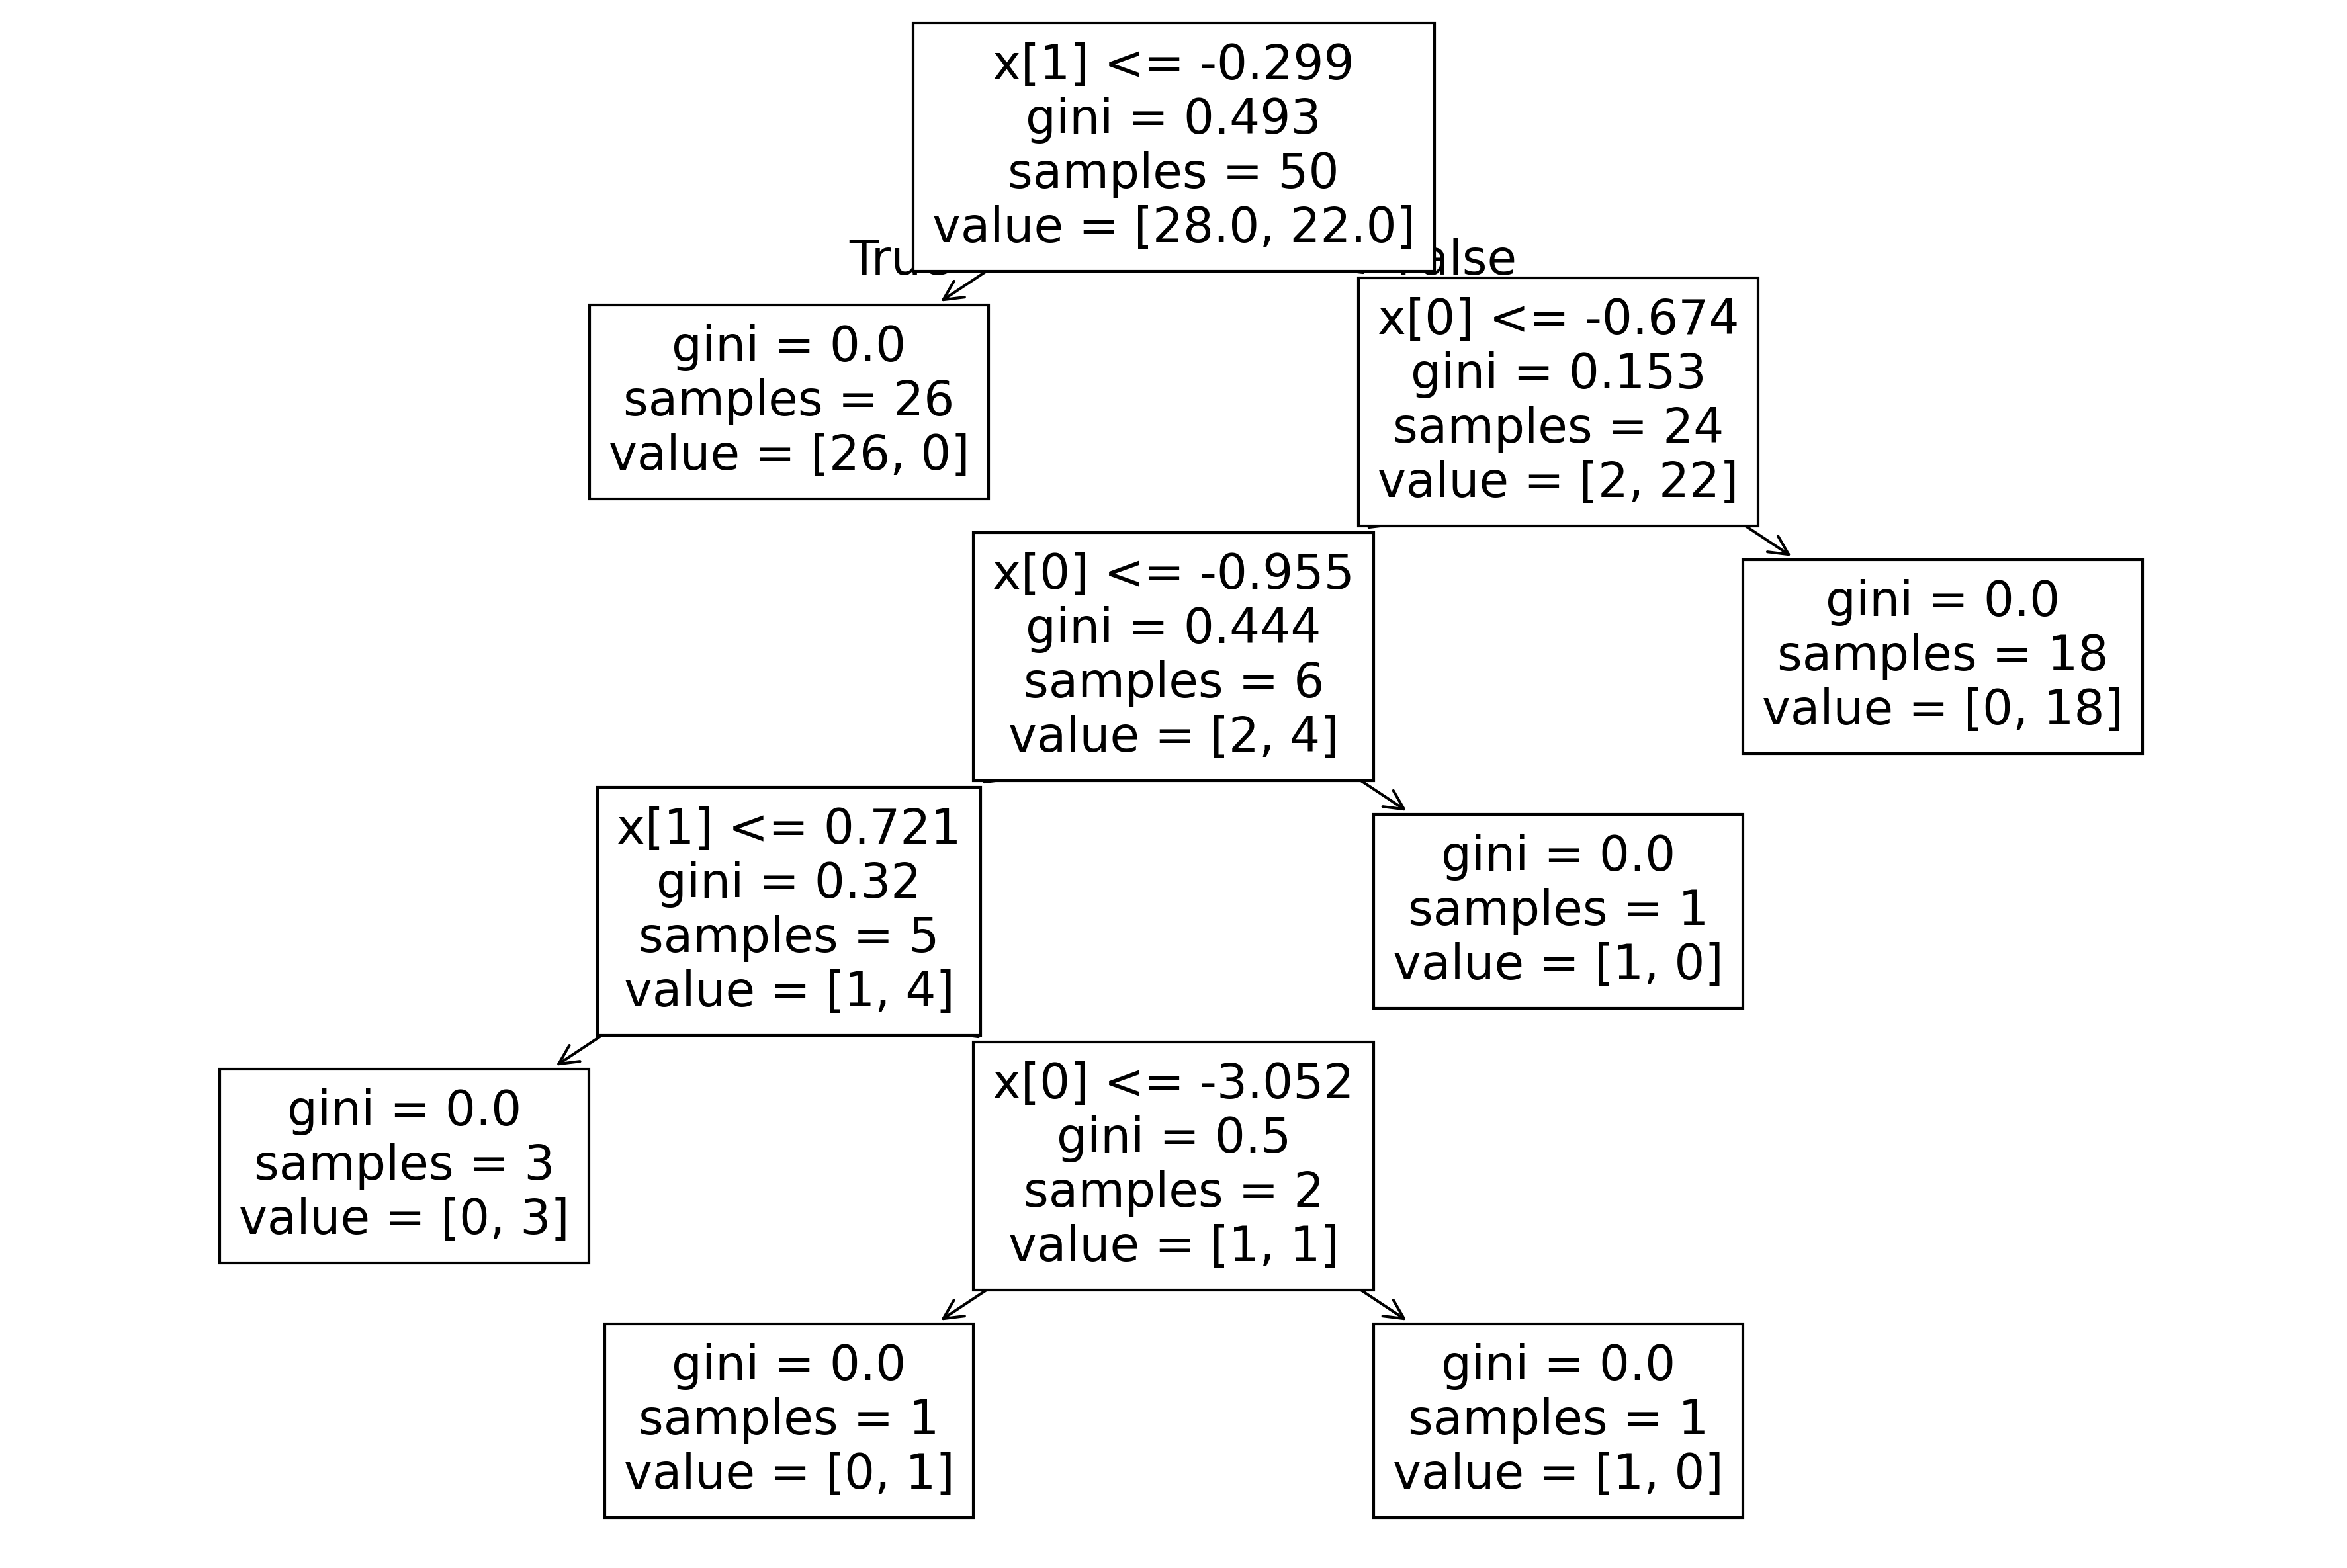

In [13]:
plt.figure(figsize=(15, 10), dpi=300)
plot_tree(clf2)

[Text(0.4, 0.9444444444444444, 'x[0] <= -0.248\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.3, 0.8333333333333334, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.35, 0.8888888888888888, 'True  '),
 Text(0.5, 0.8333333333333334, 'x[1] <= -1.694\ngini = 0.32\nsamples = 35\nvalue = [7, 28]'),
 Text(0.45, 0.8888888888888888, '  False'),
 Text(0.4, 0.7222222222222222, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6, 0.7222222222222222, 'x[0] <= 1.941\ngini = 0.219\nsamples = 32\nvalue = [4, 28]'),
 Text(0.4, 0.6111111111111112, 'x[1] <= 0.556\ngini = 0.18\nsamples = 30\nvalue = [3, 27]'),
 Text(0.3, 0.5, 'x[1] <= 0.545\ngini = 0.305\nsamples = 16\nvalue = [3, 13]'),
 Text(0.2, 0.3888888888888889, 'x[0] <= 0.075\ngini = 0.231\nsamples = 15\nvalue = [2, 13]'),
 Text(0.1, 0.2777777777777778, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3, 0.2777777777777778, 'x[0] <= 1.418\ngini = 0.133\nsamples = 14\nvalue = [1, 13]'),
 Text(0.2, 0.16666666666666666, 'gini 

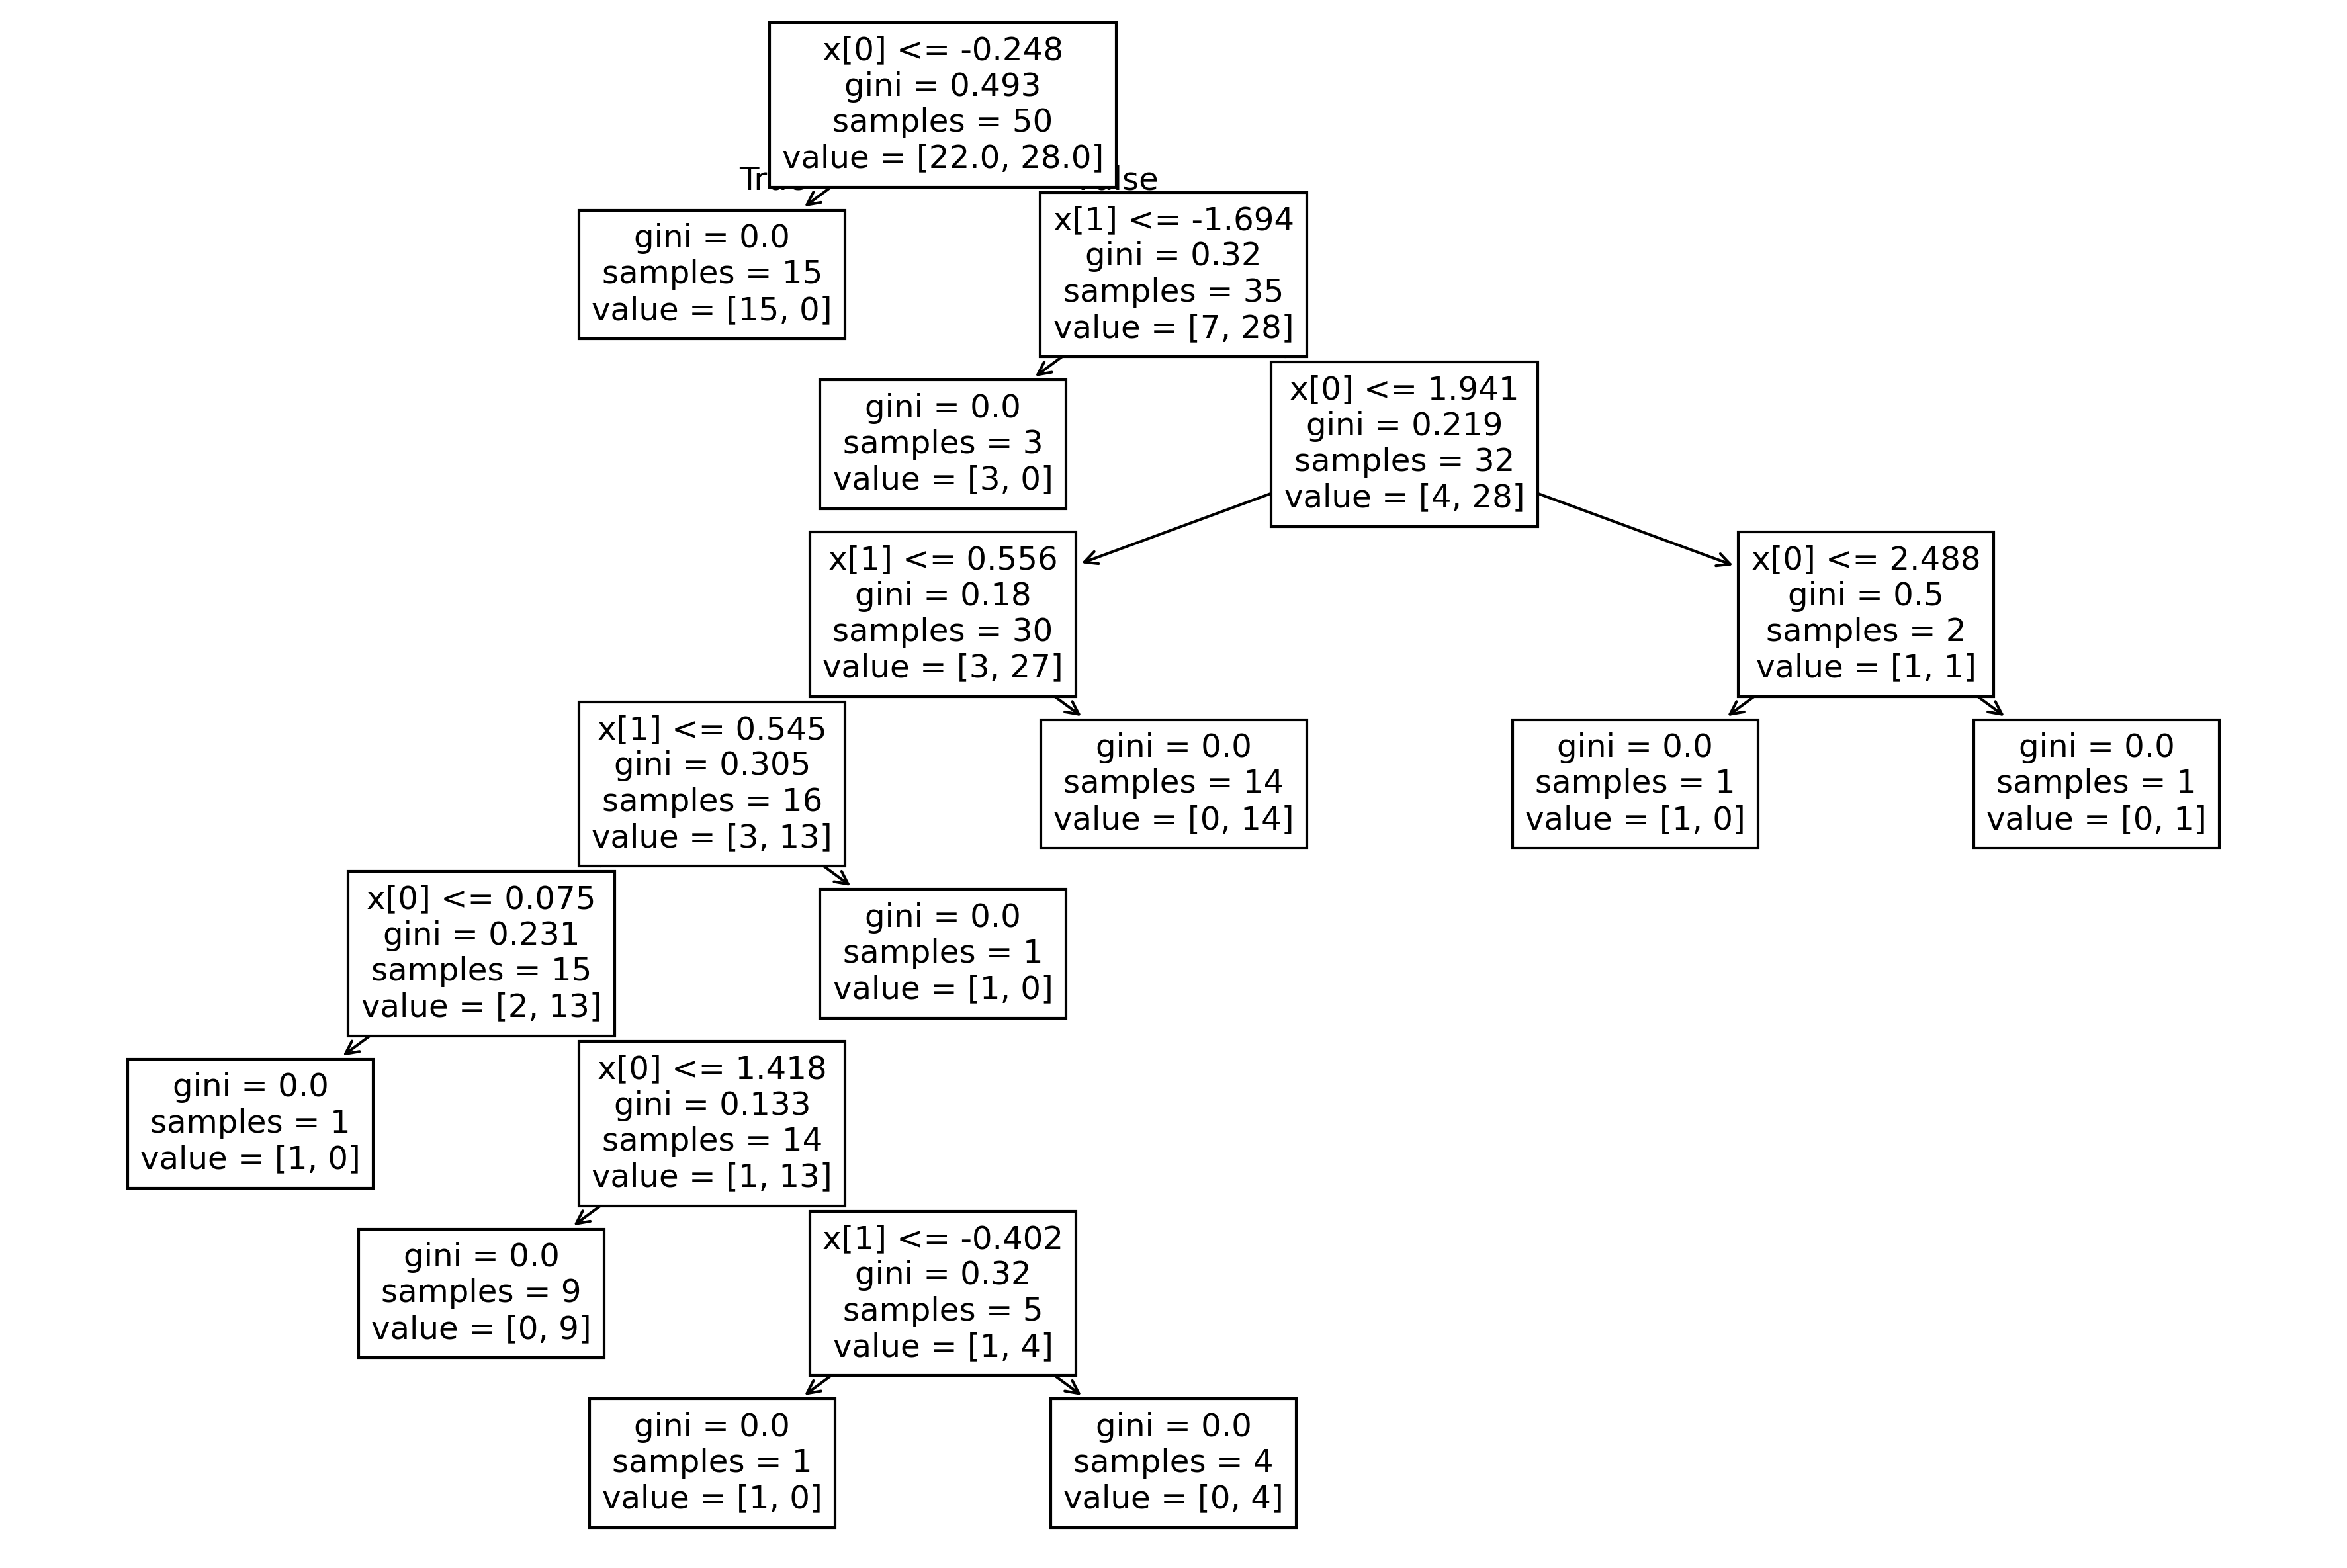

In [14]:
plt.figure(figsize=(15, 10), dpi=300)

plot_tree(clf3)

In [15]:

clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [16]:

clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))
     

d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [17]:

clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])